# 🍔 Swiggy Analysis


🎯 Objective

The goal of this project is to analyze Swiggy sales data to understand:

- Revenue trends and sales performance over time
- Top-performing restaurants, cities, and food categories
- Customer rating patterns and their impact on sales
- Most ordered dishes and customer preferences
- Order value distribution and spending behavior

📌 Problem Statement

- Understanding customer preferences and sales trends is essential for improving business performance. 
- This project analyzes Swiggy sales data to identify key factors influencing revenue, restaurant success, and customer satisfaction.

In [4]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# 📥 Load Dataset
df = pd.read_csv(r"C:\Users\A\OneDrive\Desktop\Restart\Python\Swiggy\Dataset\swiggy_data.csv")

In [ ]:
# Preview first 5 rows
df.sample(5)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
122383,Bihar,Patna,09-07-2025,7th Heaven,Hajipur,Recommended,Black Forest Pastry,78.0,4.5,32
2760,Karnataka,Bengaluru,02-02-2025,NH1 Bowls - Highway To North,Rajarajeshwari Nagar,Thanda & Meetha,Creamy Butterscotch Mousse Cake,99.0,4.5,2
76465,Tamil Nadu,Chennai,14-02-2025,Sweet Truth - Cake and Desserts,Anna Nagar,Recommended,Peanut Butter Cheesecake Slice,199.0,4.4,0
136731,Kerala,Kochi,05-02-2025,The Coconut,Kolenchery,Coconut Special Biriyani,Chicken Biryani,240.0,4.5,27
90133,West Bengal,Kolkata,24-01-2025,So Southy,New Town,Malgaipodi dosa,Malgaipodi Plain Dosa,155.0,4.4,0


In [7]:
# Shape of the Dataset
df.shape

(197430, 10)

In [8]:
# 📊 Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   State            197430 non-null  str    
 1   City             197430 non-null  str    
 2   Order Date       197430 non-null  str    
 3   Restaurant Name  197430 non-null  str    
 4   Location         197430 non-null  str    
 5   Category         197430 non-null  str    
 6   Dish Name        197430 non-null  str    
 7   Price (INR)      197430 non-null  float64
 8   Rating           197430 non-null  float64
 9   Rating Count     197430 non-null  int64  
dtypes: float64(2), int64(1), str(7)
memory usage: 15.1 MB


In [9]:
# Column Names
df.columns.tolist()

['State',
 'City',
 'Order Date',
 'Restaurant Name',
 'Location',
 'Category',
 'Dish Name',
 'Price (INR)',
 'Rating',
 'Rating Count']

In [10]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price (INR),197430.0,268.512920,219.338363,0.95,139.0,229.0,329.0,8000.0
Rating,197430.0,4.341582,0.422585,1.50,4.3,4.4,4.5,5.0
Rating Count,197430.0,28.321805,87.542593,0.00,0.0,2.0,15.0,999.0


In [11]:
# Missing Values Check
df.isnull().sum()

State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

In [12]:
# Duplicate Records Check
df.duplicated().sum()

np.int64(27)

In [13]:
# Remove Duplicate Records
df.drop_duplicates(inplace=True)

In [14]:
# Dataset Preview
df.head(5)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,29-06-2025,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,03-04-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,15-01-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,17-04-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,13-03-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [15]:
# Rename Columns
df.columns = df.columns.str.replace(' ', '_').str.replace('(', '').str.replace(')', '')


In [16]:
# Verify Updated Columns
df.head(2)

,State,City,Order_Date,Restaurant_Name,Location,Category,Dish_Name,Price_INR,Rating,Rating_Count
0,Karnataka,Bengaluru,29-06-2025,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,03-04-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25


In [17]:
# Dataset Shape After Cleaning
df.shape

(197403, 10)

In [18]:
# Convert Date Column

df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', dayfirst=True)

In [19]:
# Feature Engineering

df['YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)
df['DayName']   = df['Order_Date'].dt.day_name()
df['Quarter']   = df['Order_Date'].dt.to_period('Q').astype(str)
df['Month']     = df['Order_Date'].dt.month
df['Year']      = df['Order_Date'].dt.year

print("Columns after feature engineering:", df.columns.tolist())

Columns after feature engineering: ['State', 'City', 'Order_Date', 'Restaurant_Name', 'Location', 'Category', 'Dish_Name', 'Price_INR', 'Rating', 'Rating_Count', 'YearMonth', 'DayName', 'Quarter', 'Month', 'Year']


In [ ]:
df.shape

(197403, 15)

In [ ]:
df.head()

,State,City,Order_Date,Restaurant_Name,Location,Category,Dish_Name,Price_INR,Rating,Rating_Count,YearMonth,DayName,Quarter,Month,Year
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,2025-06,Sunday,2025Q2,6,2025
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,2025-04,Thursday,2025Q2,4,2025
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,2025-01,Wednesday,2025Q1,1,2025
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,2025-04,Thursday,2025Q2,4,2025
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,2025-03,Thursday,2025Q1,3,2025


In [22]:
# KPI Calculations

total_sales     = round(df['Price_INR'].sum(), 2)
avg_rating      = round(df['Rating'].mean(), 2)
avg_order_value = round(df['Price_INR'].mean(), 2)
ratings_count   = df['Rating_Count'].sum()
total_orders    = df['Order_Date'].count()

print(f"Total Sales (INR)   : ₹{total_sales:,.2f}")
print(f"Average Rating      : {avg_rating}")
print(f"Avg Order Value     : ₹{avg_order_value}")
print(f"Total Rating_Count  : {ratings_count:,}")
print(f"Total Orders        : {total_orders:,}")

Total Sales (INR)   : ₹53,002,984.47
Average Rating      : 4.34
Avg Order Value     : ₹268.5
Total Rating_Count  : 5,591,171
Total Orders        : 197,403


In [23]:
# Monthly Revenue Analysis
monthly_revenue = df.groupby('YearMonth')['Price_INR'].sum().sort_index().reset_index()
monthly_revenue

,YearMonth,Price_INR
0,2025-01,6823981.33
1,2025-02,6268161.67
2,2025-03,6572738.20
3,2025-04,6590449.00
4,2025-05,6792621.35
5,2025-06,6513865.19
6,2025-07,6650268.51
7,2025-08,6790899.22


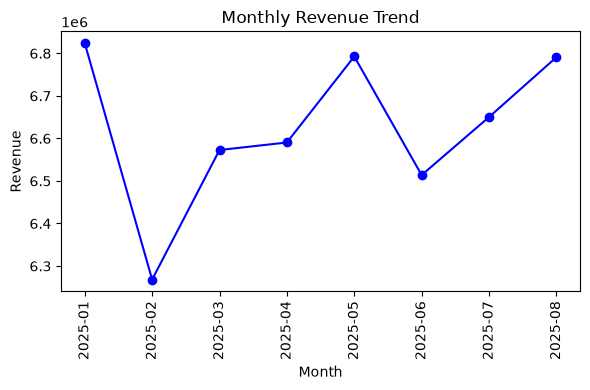

In [ ]:
# Monthly Revenue Trend Visualization
plt.figure(figsize=(6,4))
plt.plot(monthly_revenue['YearMonth'],monthly_revenue['Price_INR'],marker='o',linestyle='-',color='b')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(False)
plt.show()

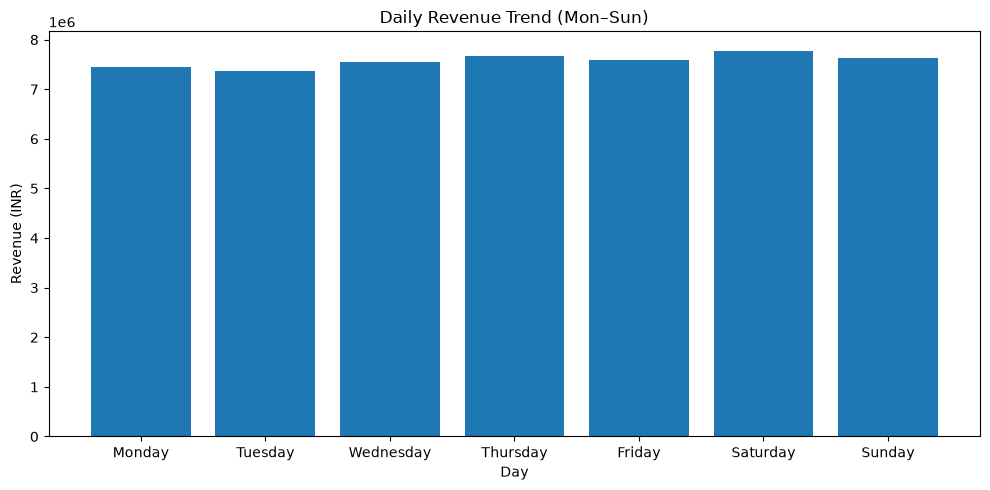

In [ ]:
# Daily Revenue Trend Visualization

daily_revenue = (
    df.groupby("DayName")["Price_INR"]
      .sum()
      .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
)
plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend (Mon–Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
quarterly_summary = (
    df.groupby("Quarter", as_index=False)
      .agg(
          Total_Sales=("Price_INR", "sum"),
          Avg_Rating=("Rating", "mean"),
          Total_Orders=("Order_Date", "count")
      )
      .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19664881.0,4.34,73085
1,2025Q2,19896936.0,4.34,74155
2,2025Q3,13441168.0,4.34,50163


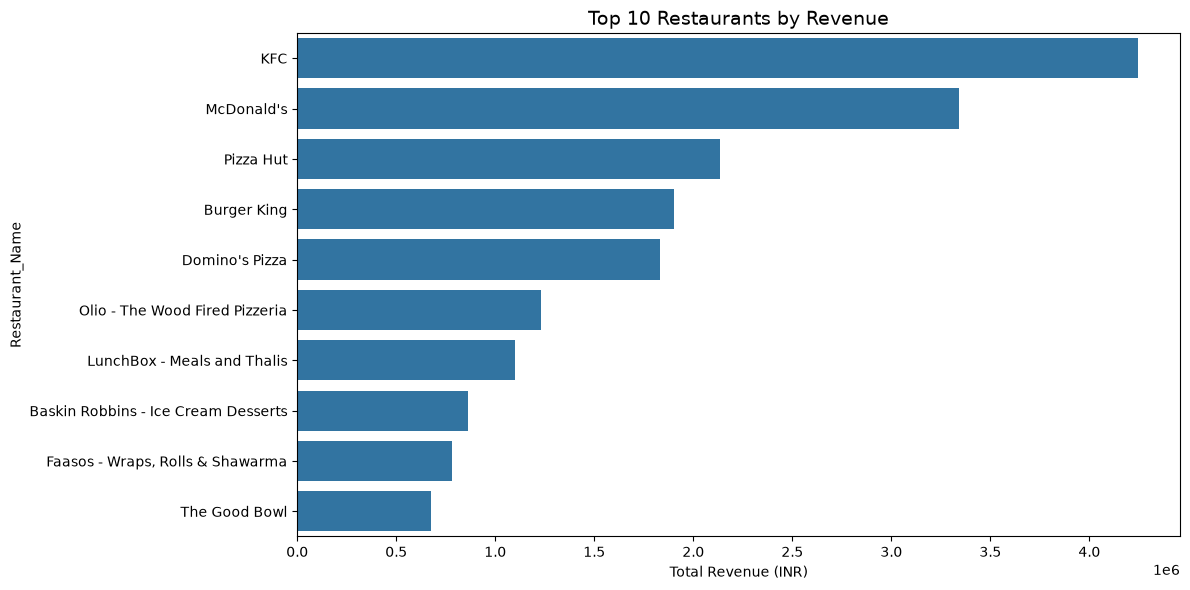

In [ ]:
# Top 10 Restaurants by Revenue 
top_restaurants = (
    df.groupby('Restaurant_Name')['Price_INR']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_restaurants, x='Price_INR', y='Restaurant_Name')
plt.title('Top 10 Restaurants by Revenue', fontsize=14)
plt.xlabel('Total Revenue (INR)')
plt.ylabel('Restaurant_Name')
plt.tight_layout()
plt.show()

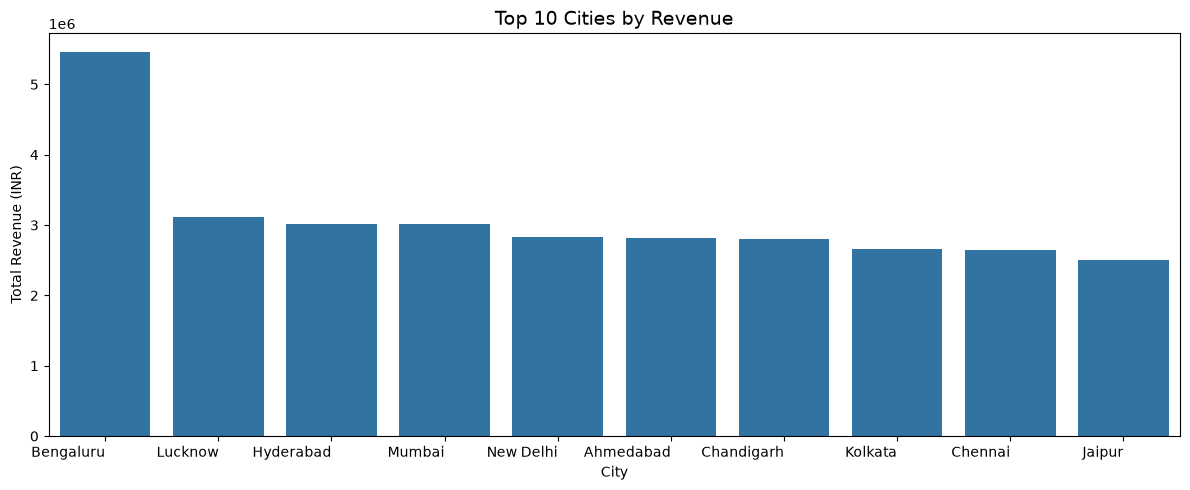

In [ ]:
# Top 10 cities by revenue
top_cities = (
    df.groupby('City')['Price_INR']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_cities, x='City', y='Price_INR')
plt.title('Top 10 Cities by Revenue', fontsize=14)
plt.xlabel('City')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

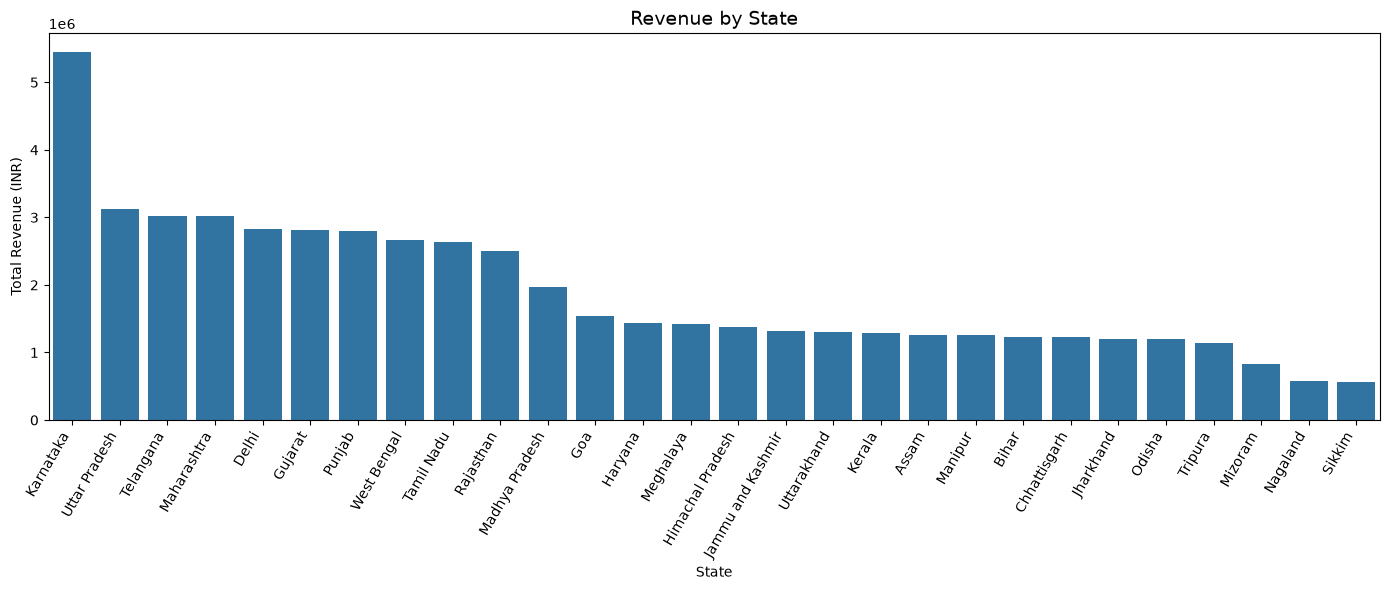

In [ ]:
# Revenue by state
state_revenue = (
    df.groupby('State')['Price_INR'].sum().sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(data=state_revenue, x='State', y='Price_INR')
plt.title('Revenue by State', fontsize=14)
plt.xlabel('State')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

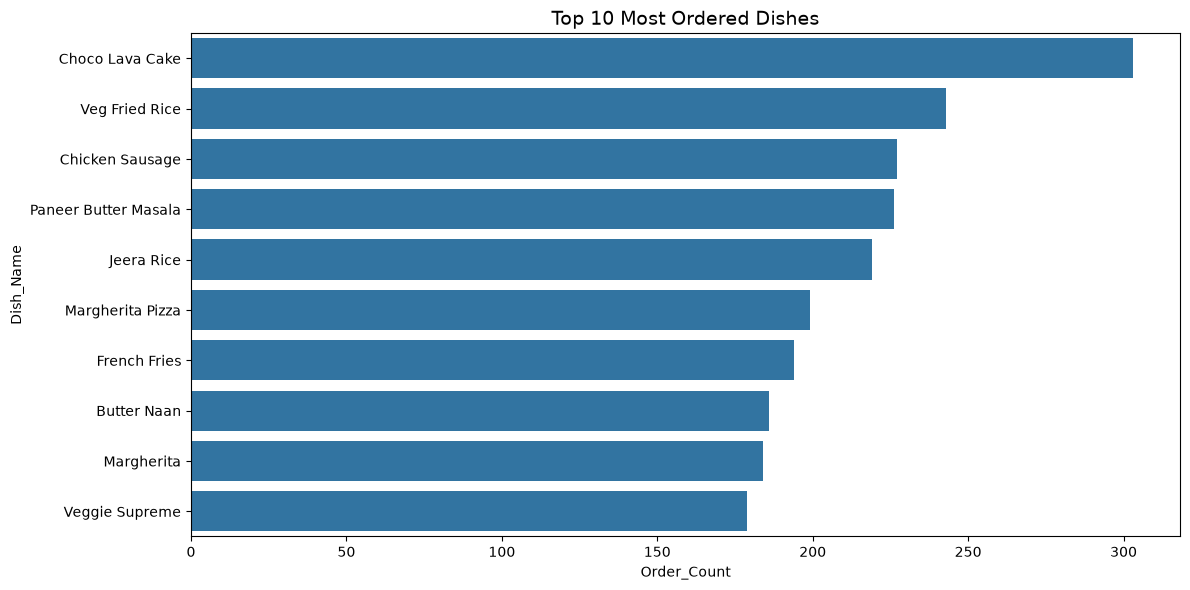

In [ ]:
# Top 10 Most Ordered Dishes
top_dishes = (
    df['Dish_Name']
      .value_counts()
      .head(10)
      .reset_index()
)
top_dishes.columns = ['Dish_Name', 'Order_Count']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_dishes, x='Order_Count', y='Dish_Name')
plt.title('Top 10 Most Ordered Dishes', fontsize=14)
plt.xlabel('Order_Count')
plt.ylabel('Dish_Name')
plt.tight_layout()
plt.show()

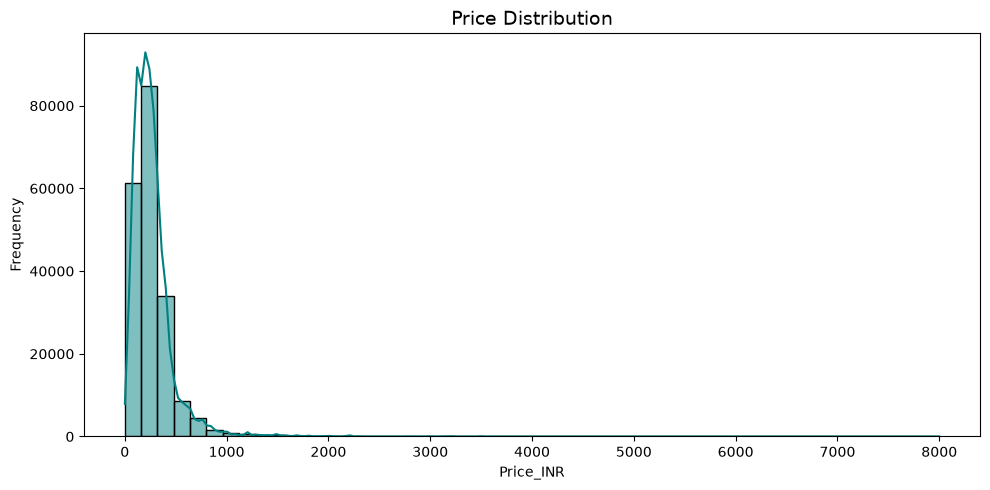

In [ ]:
# Price Distribution Visualization
plt.figure(figsize=(10, 5))
sns.histplot(df['Price_INR'], bins=50, kde=True, color='teal')
plt.title('Price Distribution', fontsize=14)
plt.xlabel('Price_INR')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

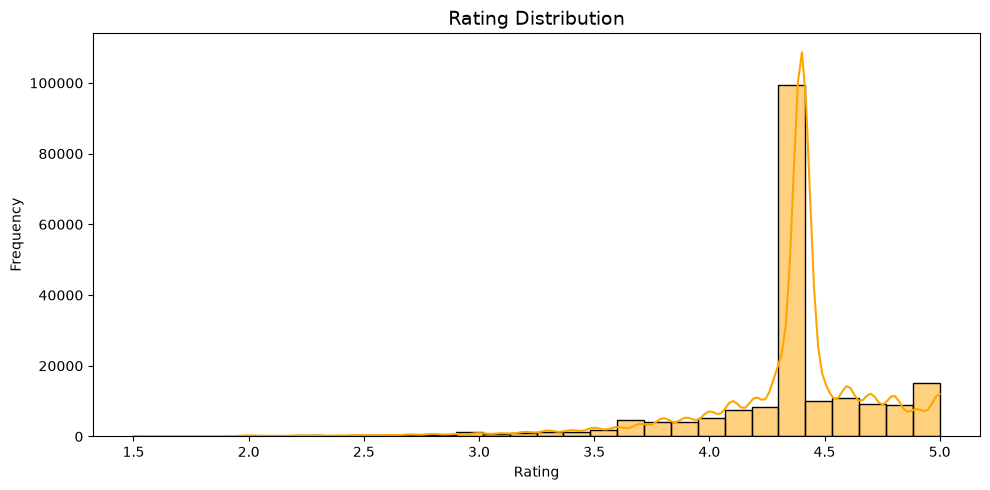

In [ ]:
# Rating Distribution Visualization
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=30, kde=True, color='orange')
plt.title('Rating Distribution', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

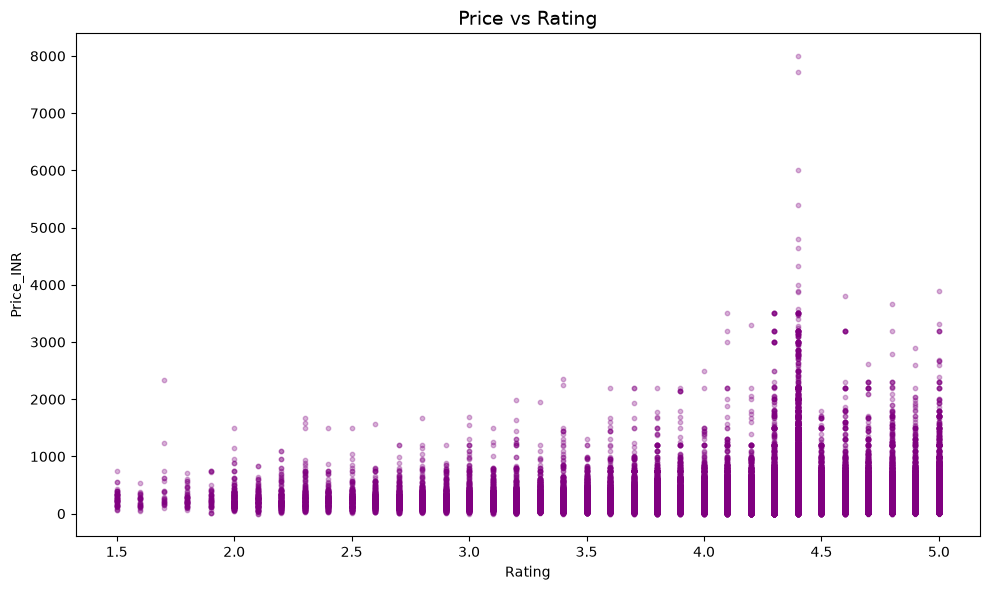


Correlation Matrix:
              Price_INR    Rating  Rating_Count
Price_INR      1.000000  0.029411     -0.101282
Rating         0.029411  1.000000      0.016161
Rating_Count  -0.101282  0.016161      1.000000


In [ ]:

plt.figure(figsize=(10, 6))
plt.scatter(df['Rating'], df['Price_INR'], alpha=0.3, color='purple', s=10)
plt.title('Price vs Rating', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Price_INR')
plt.tight_layout()
plt.show()

# Correlation
corr = df[['Price_INR', 'Rating', 'Rating_Count']].corr()
print("\nCorrelation Matrix:")
print(corr)

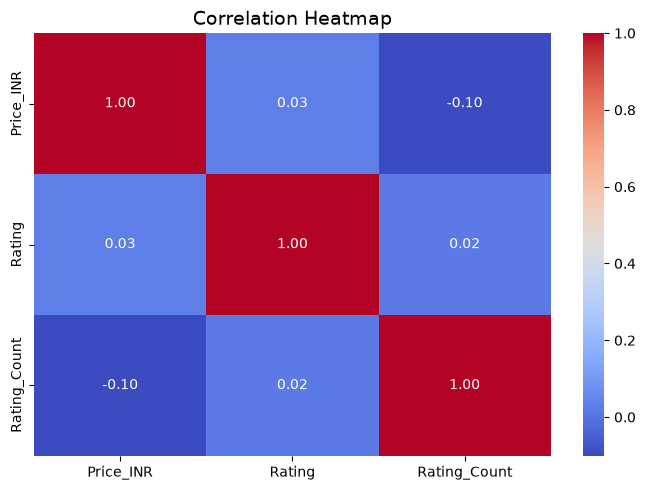

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['Price_INR', 'Rating', 'Rating_Count']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

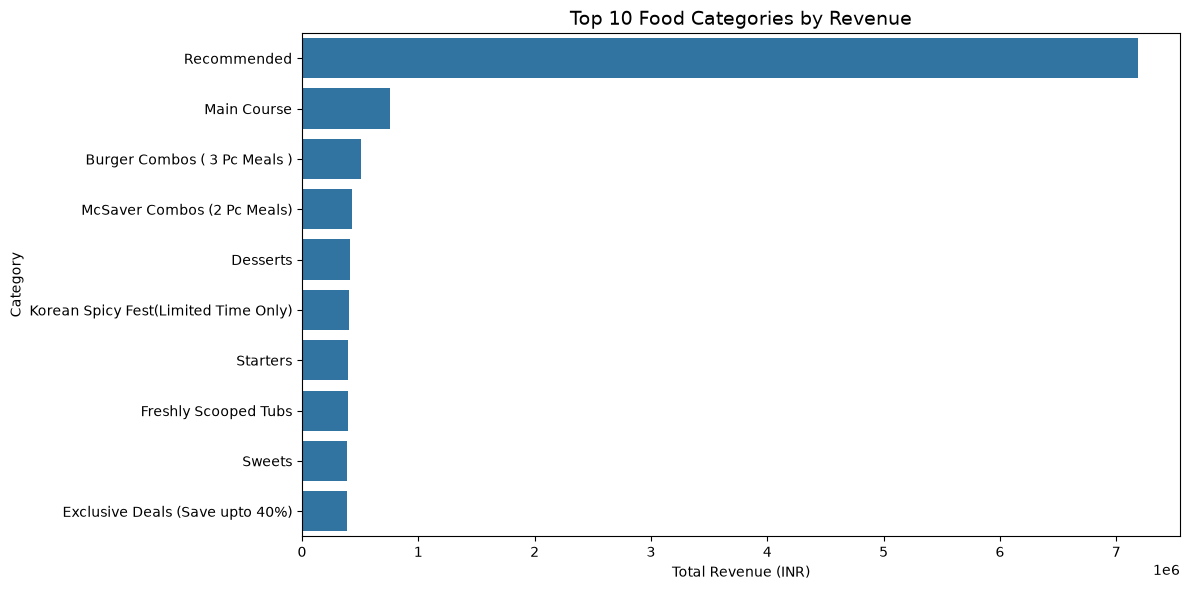

In [ ]:

top_categories = (
    df.groupby('Category')['Price_INR']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='Price_INR', y='Category')
plt.title('Top 10 Food Categories by Revenue', fontsize=14)
plt.xlabel('Total Revenue (INR)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print("       SWIGGY DATA ANALYSIS — KEY INSIGHTS")
print("=" * 55)
print(f"  Total Orders       : {total_orders:,}")
print(f"  Total Revenue      : ₹{total_sales:,.2f}")
print(f"  Avg Order Value    : ₹{avg_order_value}")
print(f"  Avg Rating         : {avg_rating} / 5.0")
print(f"  Total Ratings Given: {ratings_count:,}")
print("-" * 55)
print(f"  Top City     : {top_cities.iloc[0]['City']}")
print(f"  Top State    : {state_revenue.iloc[0]['State']}")
print(f"  Top Dish     : {top_dishes.iloc[0]['Dish_Name']}")
print(f"  Top Restaurant: {top_restaurants.iloc[0]['Restaurant_Name']}")
print("=" * 55)

       SWIGGY DATA ANALYSIS — KEY INSIGHTS
  Total Orders       : 197,403
  Total Revenue      : ₹53,002,984.47
  Avg Order Value    : ₹268.5
  Avg Rating         : 4.34 / 5.0
  Total Ratings Given: 5,591,171
-------------------------------------------------------
  Top City     : Bengaluru
  Top State    : Karnataka
  Top Dish     : Choco Lava Cake
  Top Category : Recommended
  Top Restaurant: KFC


🔍 KEY INSIGHTS:
1. Revenue trends show seasonality across months.
2. Weekend sales are typically higher.
3. Higher ratings slightly correlate with higher order value.
4. Certain items contribute disproportionately to revenue.